Imports

In [1]:
%load_ext autoreload
%autoreload 2

import pickle as pkl
import numpy as np
import json
from os.path import sep
import cv2
from glob import glob
import matplotlib
import matplotlib.pyplot as plt
import select_files
import scienceplots
from scipy.interpolate import interp1d
from generate_training import modelist
import power_length_analysis
import Meta_classifier
import socket



plt.style.use(['science', 'ieee', 'no-latex'])

plt.rcParams.update({
    'figure.figsize': [7.2, 7.2],
    'font.size': 12,
    'figure.dpi': 100,
    'savefig.dpi': 300
})



C:\Users\photonbec\anaconda3\envs\Phase_analysis\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
C:\Users\photonbec\anaconda3\envs\Phase_analysis\Lib\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might inv

# Open and format data

In [2]:
# t_stamps = ['20240731_152730', '20240731_155505']

if socket.gethostname() == 'ph-photonbec5':
    sys_path = r'D:\Data\2024'
else:
    raise Exception('Unrecognized hostname')


t_chunks = [
    ['20240805_165517','20240805_172704'],
    ['20240805_190016','20240805_194134'],
    ['20240805_215133','20240805_224241'],
    ['20240805_225747','20240805_233845'],
    ['20240805_234747','20240806_002829'],
    ['20240806_094407','20240806_102520'],
    ]


image_dir = sys_path + r'\202408'
#Make new folder or everything will be deleted
crop_dir = sys_path + r'\202408\Cropped_Images\22_07_disp_6_crop'

files, metas = select_files.open_img_files(t_chunks, image_dir)


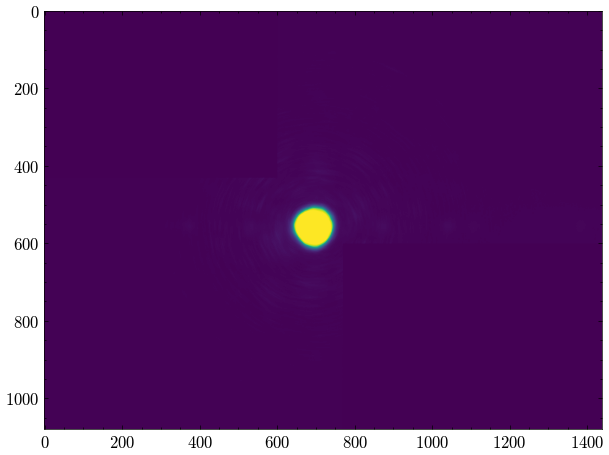

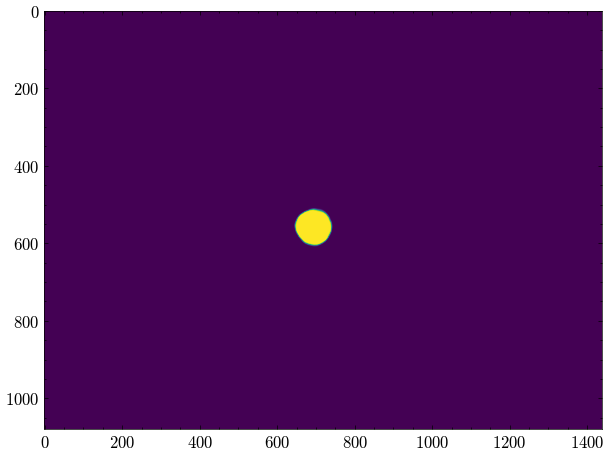

In [3]:
bec_file = sys_path + r"\202408\20240803/pbec_20240803_002215_4.0_0.07632187792076667_952.5397338867188_8.0_.png"


power_length_analysis.bec_crop_centre(bec_file, files, [170,170], crop_dir)

In [4]:
print(len(files))
files = np.array(glob(crop_dir  + sep + '*.png'))
print(len(files))
data = power_length_analysis.data_from_metas(metas, files)

720
720


# Threshold plot

In [5]:
# stim_mask = select_files.select_stimulated_nd(data)
# stim_mask = select_files.select_stimulated_exp(data, 5)
stim_mask = select_files.select_stimulated_exp_from_filename(data['file'], 1000)


20240805172704
924.7892456054688


D:\Experiments\Semiconductor Cavity\Supervised-clustering-phase-pBEC\MultiMode Analysis\power_length_analysis.py:146: RankWarning: Polyfit may be poorly conditioned
  popt = np.polyfit(pcas, lengths, 3)


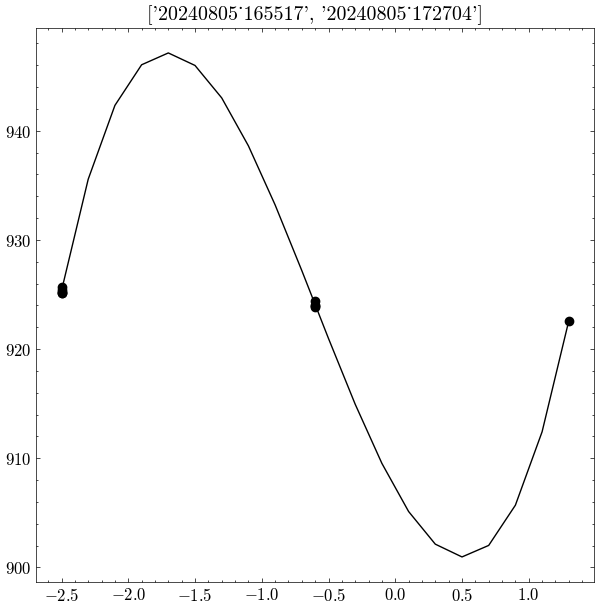

20240805194134
930.5589599609375


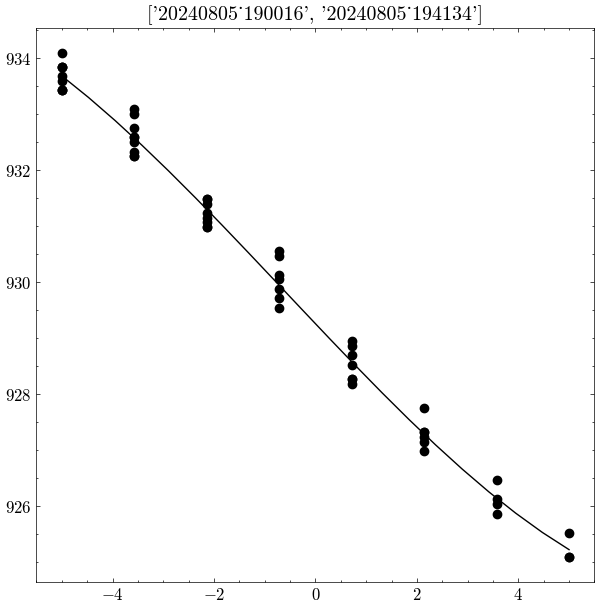

20240805224241
938.5771484375


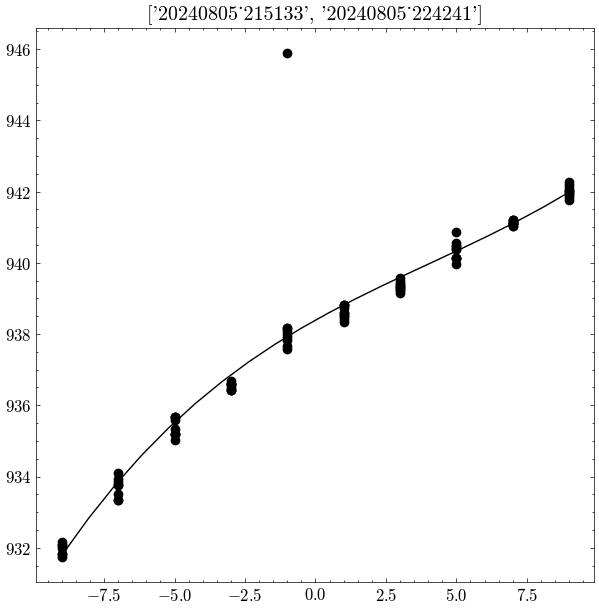

20240805233845
947.1715087890625


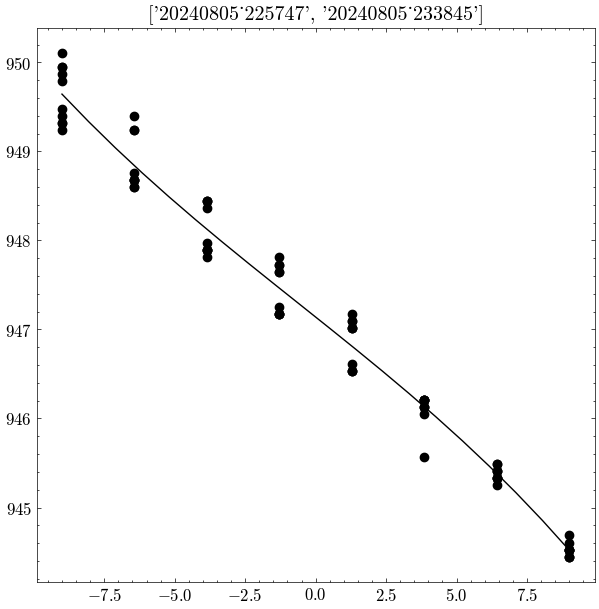

20240806002829
954.56201171875


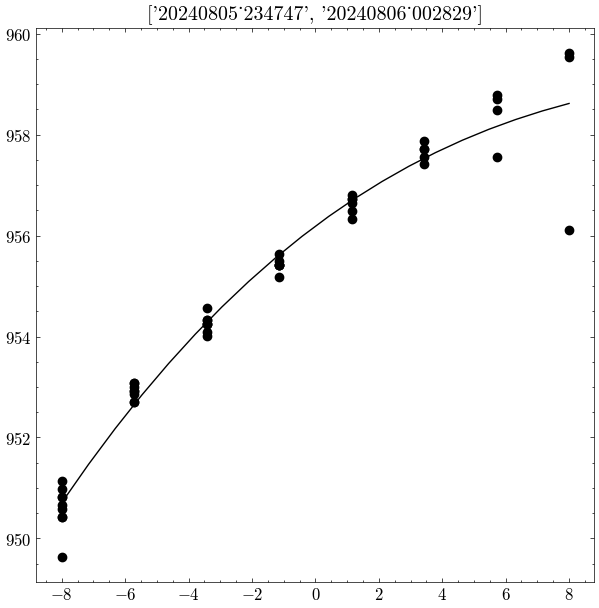

20240806102520
956.8744506835938


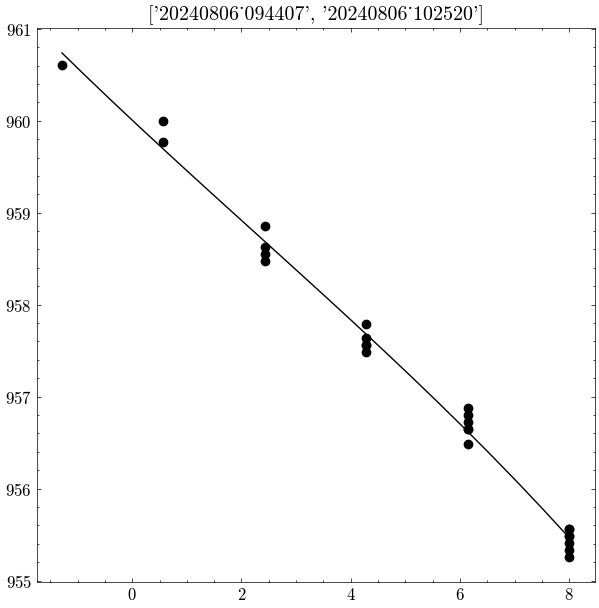

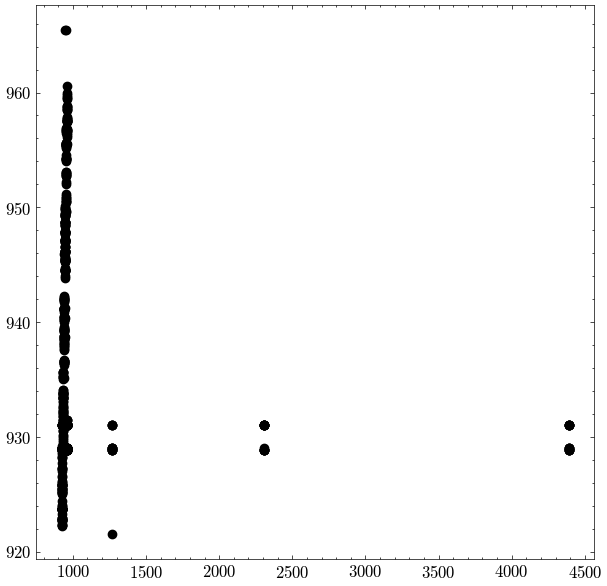

In [6]:


# Fit PCA values to cavity length
if 'pca' not in data.keys():
    print('!')
    png_data = power_length_analysis.data_dict(files)
    data.update({'pca': png_data['pca']})

pca_length = []

for i in t_chunks:
    # Creates mask for stimulated emission and each time cavity is locked
    mint = int(i[0].split('_')[0] + i[0].split('_')[1])
    maxt = int(i[1].split('_')[0] + i[1].split('_')[1])
    print(maxt)
    tmask = (mint <= data['t']) & (data['t'] <= maxt)
    mask = tmask & stim_mask


    # plt.scatter(data['cavity_length'][mask], data['power'][mask])
    # plt.show()

    mean_length = np.median(data['cavity_length'][mask])
    print(mean_length)
    length_mask = (mean_length - 10 <= data['cavity_length']) & (data['cavity_length']  <= mean_length + 10)
    mask = tmask & stim_mask & length_mask
    

    plt.scatter(data['pca'][mask], data['cavity_length'][mask])
    # plt.show()
    # fits pca values to cavity length
    _, fit = power_length_analysis.fit_pca(data['cavity_length'][mask], data['pca'][mask])
    pca_length += list(fit(data['pca'][tmask]))



    x = np.linspace(min(data['pca'][mask]), max(data['pca'][mask]), 20)
    plt.plot(x, fit(x))
    plt.title(i)
    plt.show()

data.update({'pca_length': np.array(pca_length)})


plt.scatter(data['pca_length'], data['cavity_length'])
plt.show()

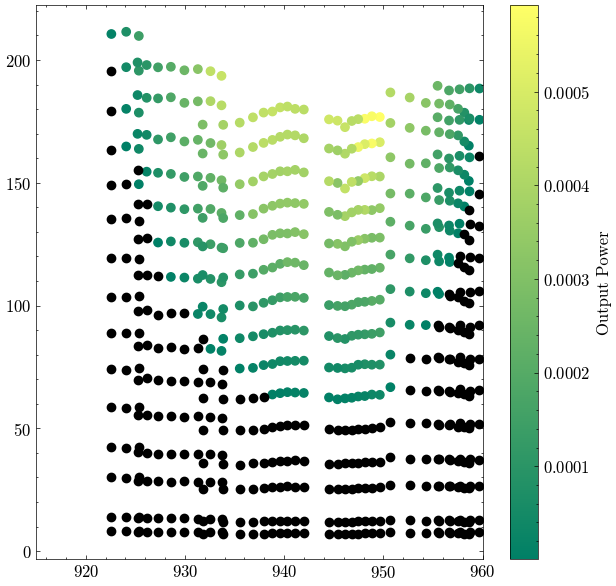

In [7]:
fig, ax = plt.subplots(1,1)
# Thermal cloud histogram
# power_length_analysis.plot_2dhist(
#     data['cavity_length'][~stim_mask],
#     data['power'][~stim_mask],
#     [910,970], [0,120],
#     'grey', 30, fig = fig, ax = ax, alpha = 1
# )

# # Stimulated emission histogram
# power_length_analysis.plot_2dhist(
#     data['cavity_length'][stim_mask],
#     data['power'][stim_mask],
#     [910,970], [0,120],
#     'orchid', 30, fig = fig, ax = ax, alpha= 1
# )

# print(data['pca_length'][stim_mask])

# Scattered points
scat = ax.scatter(data['pca_length'][stim_mask], data['power'][stim_mask], c = data['meter_reading'][stim_mask], cmap= 'summer', label = 'Above Threshold')
ax.scatter(data['pca_length'][~stim_mask], data['power'][~stim_mask], color = 'black', label = 'Below Threshold')
ax.set_xlim([915,960])
cbar = fig.colorbar(scat, ax = ax, label = 'Output Power')
plt.show()



# Interactive Plot
Below threshold is one colour, above thershold is another colour. There will be one point with a random colour, because there must be a minimum of three labels to assign colours.

In [8]:
labels = np.ones(len(data['power']))
labels[stim_mask] = 0
labels[-1] = 2

power_length_analysis.interactive_scatter(data['pca_length'], data['power'], data['file'], labels_data = labels, x_min = 915, x_max = 965)

# Basic Clustering

Kmeans

C:\Users\photonbec\anaconda3\envs\Phase_analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\photonbec\anaconda3\envs\Phase_analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


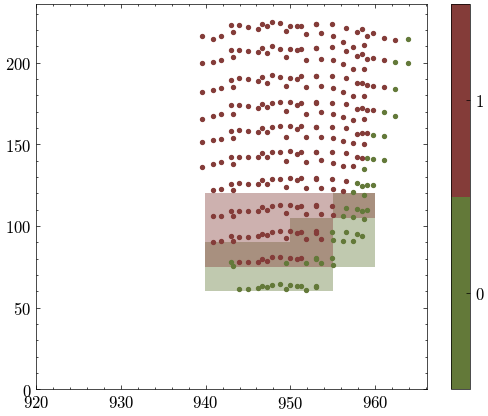

In [30]:
# Kmeans clustering on images
cluster_labels, _ = Meta_classifier.Kmeans_no_CNN(data['file'][stim_mask], 2)

# Plots each cluster
fig, ax, _, _ = power_length_analysis.all_cluster_plot(
    np.amax(cluster_labels), cluster_labels, 
    data['pca_length'][stim_mask], data['power'][stim_mask],
    'tab20b', 8, [920,960], [0,120], 8
)



Fuzzy CMeans

In [10]:
fuzzy_label, alpha, mem_mat = Meta_classifier.quick_fcmeans(data['flat_image'][stim_mask], 2, 1.5, return_matrix=True)

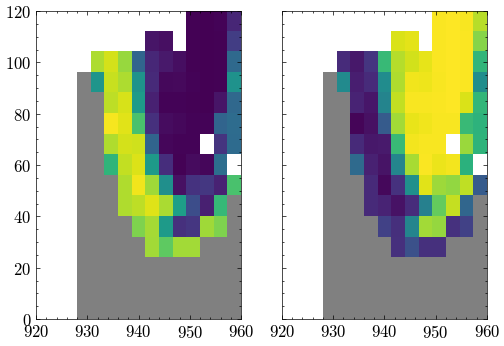

In [11]:
#num plots, num columns, num rows
fig, axes, gs = power_length_analysis.grid_plot(2, 2,1, 0.5, 0.5)

for i, col in enumerate(mem_mat):

    power_length_analysis.plot_2dhist(
        data['pca_length'][~stim_mask],
        data['power'][~stim_mask],
        [920,960], [0,240],
        'grey', 15, fig = fig, ax = axes[i], alpha = 1
    )

    power_length_analysis.plot_2d_stat_hist(
        data['pca_length'][stim_mask],
        data['power'][stim_mask],
        col,
        [920,960], [0,120], bins = 15,
        cmap = 'viridis', fig = fig, ax = axes[i]
    )


In [12]:
fuzzy_label[-1] = -1
power_length_analysis.interactive_scatter(data['pca_length'][stim_mask], data['power'][stim_mask], data['file'][stim_mask], labels_data = fuzzy_label)

# CNN

Make Predictions

In [11]:
model_root = r'C:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\MultiMode Analysis\Models\020824_multi_'
# save_path = ''
feat_vectors = Meta_classifier.predeict_images_CNN(data['file'][stim_mask], root = model_root, phases = 1, sigm=[0.2,0.1])
outputs, preds = Meta_classifier.predict_full_output(data['file'][stim_mask], root = model_root, phases = 1, sigm= [0.2,0.1])

cnn_outs = {
    'feature_vectors': feat_vectors,
    'outputs': outputs,
    'predictions': preds
}

# with open(save_path, 'w') as f:
#     json.dump(f)


0it [00:00, ?it/s]C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(
294it [00:47,  6.14it/s]
0it [00:00, ?it/s]C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(
294it [00:49,  5.97it/s]


Confidence plot

[0]


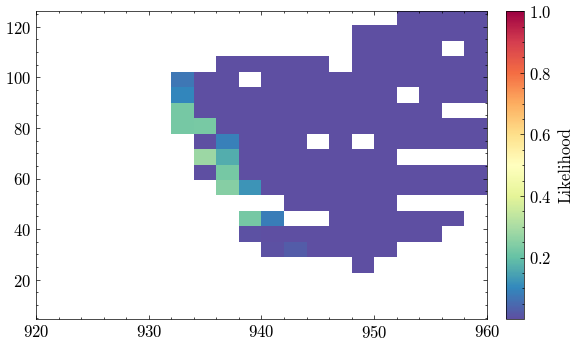

In [17]:
#Scale for all colorbars
vs = [np.min(cnn_outs['outputs']),np.max(cnn_outs['outputs'])]


fig, axes, gs = power_length_analysis.grid_plot(
    nplots = 1, ncols= 1, nrows=1, 
    wspace = 0.5, hspace = 0.5)

for i in range(cnn_outs['outputs'].shape[1]):
    mode_conf = cnn_outs['outputs'][:,i,0]
    _,_, plot, stat = power_length_analysis.plot_2d_stat_hist(data['pca_length'][stim_mask],
                                            data['power'][stim_mask],
                                            mode_conf, [920,960],
                                            [min(data['power']), max(data['power'])], bins = 20, cmap='Spectral_r',
                                            fig = fig, ax = axes[i], vs = vs, ret_stat=True) 
    
print(min(preds))

cbax = plt.subplot(gs[1])
plt.colorbar(plot, cbax,cmap = 'Spectral_r', label = 'Likelihood',)